# Naive Bayes para clasificación de sentimientos
**Alejandro Abril — Parte 1**

Este es mi aporte al proyecto. Comparo MultinomialNB y ComplementNB con BoW y TF-IDF para clasificar las reseñas como positivas, negativas o neutrales.

La versión anterior llegó a 72,25% de accuracy en validación. El problema estaba principalmente en las reseñas con elogios y quejas a la vez. Ahora pruebo la idea de conectores que usó el equipo en SVM: darle al modelo información sobre dónde aparece cada palabra y cómo empieza su frase.

También pruebo separar cláusulas, porque una misma oración puede decir “el sonido es excelente, pero la conexión es lenta”. Todos los resultados quedan en este notebook.

## 1. Base del trabajo

| Parte del experimento | Material usado |
|---|---|
| Limpieza, stemming español, BoW, TF-IDF y n-gramas | P3 de `MaterialDeClase-ISIS-2611/202620` |
| Pipeline, división estratificada, GridSearchCV y evaluación | P7 |
| Comparar promedio y variación de las métricas | Laboratorio 2, actividad 5 |
| Última oración y palabras marcadas con conectores y posición | Sección 7 de `03_SVM.ipynb` y `transformaciones.py` del equipo |

Los clasificadores son los Naive Bayes elegidos en la encuesta del grupo. Sus parámetros se explican aquí como ajustes de scikit-learn; en 202620 no encontré una práctica específica de esos clasificadores.

Después de actualizar el repositorio, uso las funciones reales del equipo: `segmentar_clausulas` y `marcar_clausulas_lote`. Separan cláusulas dentro de una oración y marcan también el conector de la cláusula anterior. Al final de `transformaciones.py` solo agregué `preparar_textos_nb`, para reproducir el stemming de la referencia anterior. Las funciones de los compañeros siguen intactas.

## 2. Entorno y librerías

Esta versión se ejecuta con **Python 3.12 y scikit-learn 1.9.0**, como acordó el equipo. Los archivos de datos deben estar en `data/`.

Las versiones usadas son las de `requirements.txt`, común a todo el equipo. En macOS: `python3.12 -m venv .venv` y `.venv/bin/python -m pip install -r requirements.txt`. En Windows: `py -3.12 -m venv .venv`, activar `.venv\Scripts\activate` y ejecutar `pip install -r requirements.txt`. Después hay que seleccionar ese entorno como kernel y ejecutar las celdas en orden.

`transformaciones.py` debe acompañar al modelo para poder cargarlo en otro computador. La búsqueda usa dos procesos; si hace falta reducir el consumo de memoria, cambiar `N_JOBS` a `1`.

In [1]:
import sys
import platform
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
import sklearn
import scipy
import joblib
import nltk
from joblib import Memory
from IPython.display import display, HTML, Markdown
from sklearn.base import clone
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, ParameterGrid, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

if sys.version_info[:2] != (3, 12) or sklearn.__version__ != "1.9.0":
    raise RuntimeError("Selecciona el entorno del equipo: Python 3.12 y scikit-learn 1.9.0.")

RAIZ = next((p for p in [Path.cwd(), Path.cwd().parent] if (p / "notebooks/04_Naive_Bayes.ipynb").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("Ejecuta desde la carpeta del proyecto o desde notebooks/.")
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from transformaciones import preparar_textos_nb, extraer_oraciones_lote, marcar_conectores_lote, marcar_clausulas_lote

SEMILLA = 42
N_FOLDS = 5
N_JOBS = 2
ALPHAS = [0.1, 0.5, 1.0, 2.0, 5.0]
versiones = {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
            "numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__,
            "joblib": joblib.__version__, "nltk": nltk.__version__}
print(versiones)

{'python': '3.12.14', 'scikit-learn': '1.9.0', 'numpy': '2.5.3', 'pandas': '3.0.6', 'scipy': '1.18.1', 'joblib': '1.6.0', 'nltk': '3.10.3'}


## 3. Cargar y revisar los datos

Reviso las columnas, las etiquetas y los textos vacíos o repetidos. Una misma reseña en entrenamiento y validación haría que el resultado pareciera mejor de lo que es. Si los datos no tienen ese problema, se conservan las 12.000 filas y la misma división de los compañeros.

In [2]:
candidatas = [Path.cwd(), Path.cwd().parent]
RAIZ = next((p for p in candidatas if (p / "notebooks/04_Naive_Bayes.ipynb").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("Ejecuta desde la raíz del proyecto o desde notebooks/.")
DATA_DIR = RAIZ / "data"
ruta_train = DATA_DIR / "train.csv"
if not ruta_train.is_file():
    raise FileNotFoundError(f"Falta {ruta_train}. Descarga el train.csv de la competencia.")

CLASES = ["negativo", "neutral", "positivo"]

def validar_datos_train(datos):
    faltantes = {"id", "text", "label"} - set(datos.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas en train.csv: {sorted(faltantes)}")
    if datos["id"].isna().any() or datos["id"].duplicated().any():
        raise ValueError("train.csv contiene identificadores vacíos o repetidos.")
    datos = datos.copy()
    textos = datos["text"].astype("string")
    etiquetas = datos["label"].astype("string")
    validos = textos.notna() & textos.str.strip().ne("") & etiquetas.notna() & etiquetas.str.strip().ne("")
    limpieza = {"filas_originales": len(datos), "filas_vacias_excluidas": int((~validos).sum())}
    datos = datos.loc[validos].copy()
    if not datos["text"].map(lambda x: isinstance(x, str)).all():
        raise ValueError("Los textos deben ser cadenas de caracteres.")
    if set(datos["label"].unique()) != set(CLASES):
        raise ValueError(f"Se esperan las tres etiquetas exactas {CLASES}. Revisa train.csv.")
    claves = datos["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    etiquetas_por_texto = datos.groupby(claves)["label"].nunique()
    if (etiquetas_por_texto > 1).any():
        raise ValueError("Hay reseñas repetidas con etiquetas contradictorias. Revisa los datos.")
    repetidos = claves.duplicated()
    limpieza["textos_repetidos_excluidos"] = int(repetidos.sum())
    datos = datos.loc[~repetidos].reset_index(drop=True)
    if datos["label"].value_counts().min() < 10:
        raise ValueError("Se necesitan al menos 10 textos distintos por clase para esta partición y CV.")
    limpieza["filas_utilizadas"] = len(datos)
    return datos, limpieza

train, limpieza = validar_datos_train(pd.read_csv(ruta_train))
print(limpieza)
display(train.head())
display(train["label"].value_counts().reindex(CLASES))

{'filas_originales': 12000, 'filas_vacias_excluidas': 0, 'textos_repetidos_excluidos': 0, 'filas_utilizadas': 12000}


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


label
negativo    4212
neutral     3576
positivo    4212
Name: count, dtype: int64

## 4. Separar entrenamiento y validación

Uso 80/20, semilla 42 y división estratificada. Dentro del entrenamiento uso cinco particiones, también estratificadas y con semilla 42. La métrica de búsqueda es **accuracy**, igual que en Kaggle y en los modelos del grupo.

El 20% ya se consultó en versiones anteriores. Los parámetros se eligen con validación cruzada; la comparación en ese 20% reutilizado sirve como referencia y no como una prueba nueva independiente. `eval.csv` solo se usa al generar las predicciones para Kaggle.

In [3]:
# P7, secciones 5 y 7: separación de datos y validación estratificada.
# Aquí usamos 80/20, semilla 42 y cinco particiones para el experimento del grupo.
X_train, X_val, y_train, y_val = train_test_split(
    train["text"], train["label"], test_size=0.20, random_state=SEMILLA, stratify=train["label"]
)
if y_train.value_counts().min() < N_FOLDS:
    raise ValueError("No hay suficientes ejemplos por clase para cinco folds.")
cv = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMILLA).split(X_train, y_train))
distribucion = pd.concat([
    y_train.value_counts(normalize=True).rename("entrenamiento"),
    y_val.value_counts(normalize=True).rename("validación_reservada"),
], axis=1).reindex(CLASES)
print(f"Entrenamiento: {len(X_train)} · Validación reservada: {len(X_val)}")
display((100 * distribucion).round(2))

Entrenamiento: 9600 · Validación reservada: 2400


,entrenamiento,validación_reservada
label,,
negativo,35.09,35.12
neutral,29.80,29.79
positivo,35.10,35.08


## 5. Qué información recibe el modelo

Comparo cuatro representaciones:

1. **Texto completo con stemming:** la preparación de la versión anterior.
2. **Última oración:** palabras y n-gramas de caracteres, como en el modelo V2 del equipo.
3. **Conectores por oraciones:** texto completo, última oración y palabras marcadas con su conector y su posición.
4. **Conectores por cláusulas:** los mismos bloques, cambiando cómo se separan las partes del texto.

Cada una se prueba con BoW y TF-IDF. La unión de bloques conserva matrices dispersas y valores no negativos, que es lo que necesitan los dos Naive Bayes. Los conectores se identifican con reglas de texto; sus asociaciones con cada clase se aprenden con los datos de entrenamiento.

In [4]:
ejemplo = "El sonido es excelente, pero la conexión es lenta. Eso sí, la batería funciona bien."
display(pd.DataFrame({
    "representación": ["Texto", "Stemming", "Última oración", "Conectores", "Cláusulas"],
    "resultado": [ejemplo, preparar_textos_nb([ejemplo])[0],
                  extraer_oraciones_lote([ejemplo])[0],
                  marcar_conectores_lote([ejemplo], palabras_conector=1)[0],
                  marcar_clausulas_lote([ejemplo], palabras_conector=1)[0]],
}))

,representación,resultado
0,Texto,"El sonido es excelente, pero la conexión es le..."
1,Stemming,el son es excelent pero la conexion es lent es...
2,Última oración,"Eso sí, la batería funciona bien."
3,Conectores,el__el el__sonido el__es el__excelente el__per...
4,Cláusulas,el__el el__sonido el__es el__excelente p3__el ...


## 6. Construir los pipelines

La preparación, el vectorizador y el clasificador van juntos en un pipeline. Así el vocabulario y los pesos TF-IDF se aprenden dentro de cada partición de entrenamiento.

`alpha` es el suavizado: evita probabilidades nulas cuando una palabra no apareció en una clase. Empiezo con cinco valores y una o dos palabras iniciales para marcar el conector. Después ajusto con más detalle los dos candidatos con mayor accuracy de CV.

La referencia anterior vuelve a competir con su configuración exacta. Para el refinamiento también pruebo los pesos de los bloques y `fit_prior` en MultinomialNB o `norm` en ComplementNB. Los pesos de los bloques son siempre positivos.

In [5]:
familias = [("BoW", "MultinomialNB"), ("BoW", "ComplementNB"),
            ("TF-IDF", "MultinomialNB"), ("TF-IDF", "ComplementNB")]
representaciones = ["texto_completo", "ultima_oracion", "conectores", "clausulas"]

def vectorizador(tipo, contexto=False, caracteres=False, min_df=2):
    clase = CountVectorizer if tipo == "BoW" else TfidfVectorizer
    opciones = {"min_df": min_df, "lowercase": True, "strip_accents": None}
    if contexto:
        opciones.update(token_pattern=r"\S+", lowercase=False, ngram_range=(1, 1))
    elif caracteres:
        opciones.update(analyzer="char", ngram_range=(3, 5))
    else:
        opciones["ngram_range"] = (1, 2)
    if tipo == "TF-IDF":
        opciones["sublinear_tf"] = True
    return clase(**opciones)

def bloque_final(tipo, caracteres=False):
    return Pipeline([
        ("extraer", FunctionTransformer(extraer_oraciones_lote, kw_args={"cantidad": 1}, validate=False)),
        ("vector", vectorizador(tipo, caracteres=caracteres)),
    ])

def crear_pipeline(tipo, modelo, representacion):
    if representacion == "texto_completo":
        rep = Pipeline([("preparar", FunctionTransformer(preparar_textos_nb, validate=False)),
                        ("vector", vectorizador(tipo))])
    elif representacion == "ultima_oracion":
        rep = FeatureUnion([("palabras", bloque_final(tipo)),
                            ("caracteres", bloque_final(tipo, caracteres=True))])
    else:
        marcar = marcar_conectores_lote if representacion == "conectores" else marcar_clausulas_lote
        rep = FeatureUnion([
            ("contexto", Pipeline([
                ("marcar", FunctionTransformer(marcar, kw_args={"palabras_conector": 1}, validate=False)),
                ("vector", vectorizador(tipo, contexto=True)),
            ])),
            ("texto", vectorizador(tipo)),
            ("ultima_palabras", bloque_final(tipo)),
            ("ultima_caracteres", bloque_final(tipo, caracteres=True)),
        ])
    clasificador = MultinomialNB() if modelo == "MultinomialNB" else ComplementNB()
    return Pipeline([("representacion", rep), ("classifier", clasificador)])

def ordenar(tabla):
    return tabla.sort_values(["accuracy_cv", "std_accuracy_cv"], ascending=[False, True], kind="stable")

def buscar(pipeline, rejilla, tipo, modelo, representacion, etapa):
    cantidad = len(ParameterGrid(rejilla))
    print(f"{representacion} / {tipo} + {modelo}: {cantidad} configuraciones ({etapa})", flush=True)
    with TemporaryDirectory(prefix="nb-cv-") as cache:
        candidato = clone(pipeline)
        candidato.memory = Memory(cache, verbose=0)
        grid = GridSearchCV(candidato, rejilla, scoring="accuracy", cv=cv,
                            n_jobs=N_JOBS, pre_dispatch=N_JOBS, error_score="raise",
                            return_train_score=True)
        grid.fit(X_train, y_train)
        mejor = grid.best_estimator_
        mejor.memory = None
        tabla = pd.DataFrame({
            "representación": representacion, "vectorizador": tipo, "modelo": modelo, "etapa": etapa,
            "accuracy_cv": grid.cv_results_["mean_test_score"],
            "std_accuracy_cv": grid.cv_results_["std_test_score"],
            "accuracy_train_cv": grid.cv_results_["mean_train_score"],
            "parametros": grid.cv_results_["params"],
        })
    fila = tabla.loc[grid.best_index_].to_dict()
    print(f"Mejor accuracy CV: {fila['accuracy_cv']:.4f}", flush=True)
    return mejor, tabla, fila

def rejilla_refinamiento(pipeline, representacion, modelo):
    alpha = pipeline.get_params()["classifier__alpha"]
    rejilla = {"classifier__alpha": sorted({round(alpha / 3, 8), alpha, round(alpha * 3, 8)})}
    if modelo == "MultinomialNB":
        rejilla["classifier__fit_prior"] = [True, False]
    else:
        rejilla["classifier__norm"] = [False, True]
    if representacion in {"conectores", "clausulas"}:
        rejilla["representacion__transformer_weights"] = [
            None,
            {"contexto": 2.0, "texto": 1.0, "ultima_palabras": 1.0, "ultima_caracteres": 1.0},
            {"contexto": 1.0, "texto": 1.0, "ultima_palabras": 2.0, "ultima_caracteres": 2.0},
        ]
    elif representacion == "ultima_oracion":
        rejilla["representacion__transformer_weights"] = [
            None, {"palabras": 2.0, "caracteres": 1.0}, {"palabras": 1.0, "caracteres": 2.0},
        ]
    else:
        rejilla["representacion__vector__min_df"] = [1, 2, 5]
    return rejilla

## 7. Ejecutar la búsqueda

Todos los candidatos usan las mismas cinco particiones y solo el 80% de entrenamiento. La caché temporal evita repetir parte de la vectorización y se borra al terminar cada búsqueda.

La selección usa accuracy de CV. Si los finalistas empatan, comparo F1 macro de CV y después su desviación. La validación reservada se revisa después de fijar el modelo.

In [6]:
tablas, filas, candidatos = [], [], {}

def registrar(clave, pipeline, tabla, fila):
    tablas.append(tabla)
    filas.append({**fila, "clave": clave})
    candidatos[clave] = pipeline

referencia, tabla, fila = buscar(
    crear_pipeline("TF-IDF", "MultinomialNB", "texto_completo"),
    {"classifier__alpha": [2.0], "classifier__fit_prior": [True],
     "representacion__vector__min_df": [1], "representacion__vector__sublinear_tf": [False]},
    "TF-IDF", "MultinomialNB", "texto_completo", "referencia_anterior",
)
fila_referencia = fila.copy()
registrar("referencia_anterior", referencia, tabla, fila)

for representacion in representaciones:
    for tipo, modelo in familias:
        rejilla = {"classifier__alpha": ALPHAS}
        if representacion in {"conectores", "clausulas"}:
            rejilla["representacion__contexto__marcar__kw_args"] = [
                {"palabras_conector": 1}, {"palabras_conector": 2},
            ]
        pipe, tabla, fila = buscar(crear_pipeline(tipo, modelo, representacion), rejilla,
                                   tipo, modelo, representacion, "comparacion_inicial")
        registrar(f"{representacion} / {tipo} / {modelo}", pipe, tabla, fila)

iniciales = ordenar(pd.DataFrame(filas)).head(2)
for _, inicial in iniciales.iterrows():
    pipe, tabla, fila = buscar(candidatos[inicial["clave"]],
                               rejilla_refinamiento(candidatos[inicial["clave"]], inicial["representación"], inicial["modelo"]),
                               inicial["vectorizador"], inicial["modelo"], inicial["representación"], "refinamiento")
    registrar(inicial["clave"] + " / refinado", pipe, tabla, fila)

tabla_experimentos = ordenar(pd.concat(tablas, ignore_index=True))
tabla_finalistas = ordenar(pd.DataFrame(filas))
por_familia = tabla_finalistas.drop_duplicates(["vectorizador", "modelo"]).copy()
por_familia["f1_macro_cv"] = [
    cross_val_score(candidatos[fila["clave"]], X_train, y_train,
                    scoring="f1_macro", cv=cv, n_jobs=N_JOBS).mean()
    for _, fila in por_familia.iterrows()
]
por_familia = por_familia.sort_values(["accuracy_cv", "f1_macro_cv", "std_accuracy_cv"], ascending=[False, False, True])
mejor_resultado = por_familia.iloc[0]
mejor_modelo = candidatos[mejor_resultado["clave"]]
print("Modelo elegido por CV:", mejor_resultado["clave"])
print("Parámetros:", mejor_resultado["parametros"])

texto_completo / TF-IDF + MultinomialNB: 1 configuraciones (referencia_anterior)
Mejor accuracy CV: 0.7150
texto_completo / BoW + MultinomialNB: 5 configuraciones (comparacion_inicial)
Mejor accuracy CV: 0.7112
texto_completo / BoW + ComplementNB: 5 configuraciones (comparacion_inicial)
Mejor accuracy CV: 0.6663
texto_completo / TF-IDF + MultinomialNB: 5 configuraciones (comparacion_inicial)
Mejor accuracy CV: 0.7146
texto_completo / TF-IDF + ComplementNB: 5 configuraciones (comparacion_inicial)
Mejor accuracy CV: 0.6941
ultima_oracion / BoW + MultinomialNB: 5 configuraciones (comparacion_inicial)
Mejor accuracy CV: 0.8426
ultima_oracion / BoW + ComplementNB: 5 configuraciones (comparacion_inicial)
Mejor accuracy CV: 0.8276
ultima_oracion / TF-IDF + MultinomialNB: 5 configuraciones (comparacion_inicial)
Mejor accuracy CV: 0.8479
ultima_oracion / TF-IDF + ComplementNB: 5 configuraciones (comparacion_inicial)
Mejor accuracy CV: 0.8394
conectores / BoW + MultinomialNB: 10 configuraciones 

/Users/april/Uni/9 Semestre/Machine learning/Proyecto-Machine-Learning/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## 8. Comparar los resultados de CV

La primera tabla muestra el mejor candidato de cada combinación de vectorizador y clasificador. F1 macro se calcula también sobre las cinco particiones de entrenamiento, para revisar las tres clases con el mismo peso.

La segunda tabla compara las representaciones. La búsqueda completa se puede desplegar debajo, sin archivos adicionales de resultados.

In [7]:
tabla_comparacion = por_familia.copy()
tabla_comparacion["alpha"] = [candidatos[k]["classifier"].alpha for k in tabla_comparacion["clave"]]
display(tabla_comparacion[["modelo", "vectorizador", "representación", "alpha", "accuracy_cv", "f1_macro_cv", "std_accuracy_cv"]].round(4))
tabla_representaciones = tabla_finalistas.drop_duplicates("representación")
display(tabla_representaciones[["representación", "vectorizador", "modelo", "accuracy_cv", "std_accuracy_cv"]].round(4))
print(f"Referencia anterior: {fila_referencia['accuracy_cv']:.4f} de accuracy CV.")
print(f"Mejora de CV: {100 * (mejor_resultado['accuracy_cv'] - fila_referencia['accuracy_cv']):.2f} puntos porcentuales.")
display(HTML(f"<details><summary>Ver las {len(tabla_experimentos)} configuraciones evaluadas</summary>"
             + tabla_experimentos.round(4).to_html(index=False) + "</details>"))

Referencia anterior: 0.7150 de accuracy CV.
Mejora de CV: 16.11 puntos porcentuales.


,modelo,vectorizador,representación,alpha,accuracy_cv,f1_macro_cv,std_accuracy_cv
15,MultinomialNB,TF-IDF,clausulas,0.1,0.8761,0.8801,0.0121
13,MultinomialNB,BoW,clausulas,0.1,0.8697,0.8743,0.0133
16,ComplementNB,TF-IDF,clausulas,0.1,0.8545,0.8554,0.0133
14,ComplementNB,BoW,clausulas,0.1,0.8427,0.8434,0.0117


,representación,vectorizador,modelo,accuracy_cv,std_accuracy_cv
15,clausulas,TF-IDF,MultinomialNB,0.8761,0.0121
11,conectores,TF-IDF,MultinomialNB,0.8714,0.0089
7,ultima_oracion,TF-IDF,MultinomialNB,0.8479,0.0117
0,texto_completo,TF-IDF,MultinomialNB,0.7150,0.0151


representación,vectorizador,modelo,etapa,accuracy_cv,std_accuracy_cv,accuracy_train_cv,parametros
clausulas,TF-IDF,MultinomialNB,comparacion_inicial,0.8761,0.0121,0.9540,"{'classifier__alpha': 0.1, 'representacion__contexto__marcar__kw_args': {'palabras_conector': 1}}"
clausulas,TF-IDF,MultinomialNB,refinamiento,0.8761,0.0121,0.9540,"{'classifier__alpha': 0.1, 'classifier__fit_prior': True, 'representacion__transformer_weights': None}"
clausulas,TF-IDF,MultinomialNB,refinamiento,0.8761,0.0121,0.9538,"{'classifier__alpha': 0.1, 'classifier__fit_prior': False, 'representacion__transformer_weights': None}"
clausulas,TF-IDF,MultinomialNB,refinamiento,0.8747,0.0095,0.9657,"{'classifier__alpha': 0.03333333, 'classifier__fit_prior': True, 'representacion__transformer_weights': None}"
clausulas,TF-IDF,MultinomialNB,refinamiento,0.8747,0.0095,0.9656,"{'classifier__alpha': 0.03333333, 'classifier__fit_prior': False, 'representacion__transformer_weights': None}"
clausulas,TF-IDF,MultinomialNB,refinamiento,0.8747,0.0093,0.9770,"{'classifier__alpha': 0.03333333, 'classifier__fit_prior': True, 'representacion__transformer_weights': {'contexto': 2.0, 'texto': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}}"
clausulas,TF-IDF,MultinomialNB,refinamiento,0.8747,0.0093,0.9770,"{'classifier__alpha': 0.03333333, 'classifier__fit_prior': False, 'representacion__transformer_weights': {'contexto': 2.0, 'texto': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}}"
clausulas,TF-IDF,MultinomialNB,refinamiento,0.8741,0.0116,0.9695,"{'classifier__alpha': 0.1, 'classifier__fit_prior': True, 'representacion__transformer_weights': {'contexto': 2.0, 'texto': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}}"
clausulas,TF-IDF,MultinomialNB,refinamiento,0.8740,0.0115,0.9583,"{'classifier__alpha': 0.3, 'classifier__fit_prior': True, 'representacion__transformer_weights': {'contexto': 2.0, 'texto': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}}"
clausulas,TF-IDF,MultinomialNB,refinamiento,0.8738,0.0115,0.9582,"{'classifier__alpha': 0.3, 'classifier__fit_prior': False, 'representacion__transformer_weights': {'contexto': 2.0, 'texto': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}}"


### Qué muestran estas tablas

TF-IDF con MultinomialNB y cláusulas obtuvo **87,61%** de accuracy promedio en CV. Con conectores por oraciones llegó a **87,14%** y usando solo la última oración, a **84,79%**. La referencia de texto completo quedó en **71,50%**. En estos datos, incluir el contexto de cada opinión ayudó más que ajustar únicamente el suavizado.

Las cláusulas fueron la mejor representación para las cuatro combinaciones. MultinomialNB quedó por encima de ComplementNB: con BoW alcanzó 86,97%, mientras que ComplementNB obtuvo 85,45% con TF-IDF y 84,27% con BoW.

Se probaron **157 configuraciones**. El refinamiento de los dos mejores candidatos no mejoró la accuracy máxima. La configuración elegida usa `alpha=0.1`, una palabra inicial como conector y los pesos iguales de los cuatro bloques.


## 9. Evaluación y errores

El ganador ya quedó elegido con CV. Ahora reviso las 2.400 reseñas de validación y comparo con la referencia anterior. Este conjunto fue consultado antes; la mejora aquí no garantiza el mismo cambio en Kaggle.

Accuracy: 0.8771; F1 macro: 0.8814
Referencia anterior: 0.7225; diferencia: 15.46 puntos.
Errores: 295 de 2400


,precision,recall,f1-score,support
negativo,0.8254,0.8470,0.8361,843.0000
neutral,0.9622,0.9972,0.9794,715.0000
positivo,0.8539,0.8052,0.8289,842.0000
accuracy,0.8771,0.8771,0.8771,0.8771
macro avg,0.8805,0.8831,0.8814,2400.0000
weighted avg,0.8762,0.8771,0.8762,2400.0000


Predicción,negativo,neutral,positivo
Real,,,
negativo,714,14,115
neutral,1,713,1
positivo,150,14,678


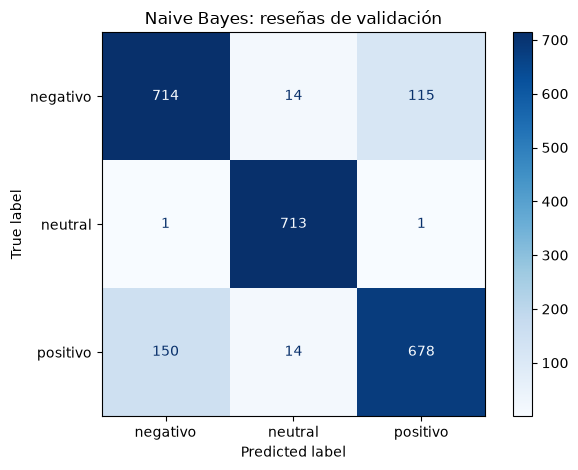

,id,texto,etiqueta_real,prediccion
7092,7092,"La compre a mediados de marzo por internet y llego en cinco dias a mi casa. No le recomiendo el peso a nadie. La uso mas que nada los fines de semana para revisar unos datos. Por cierto, el servicio funciona de maravilla. Ni lo mejor ni lo peor.",negativo,positivo
2766,2766,"Lo compré a principios de mes y ya llevo un tiempo con él, lo estoy probando a fondo en las tardes después del trabajo. El diseño fue todo un acierto, la verdad. Y no paré de tener problemas con la terminación, hubo detalles que no me gustaron. Sigo con dudas, la verdad.",positivo,negativo
9712,9712,"Lo compré a inicios de año y lo uso a diario, casi siempre en las tardes después del trabajo. Después de usarlo bastante, la verdad el rendimiento se ve inconsistente. A veces arranca bien y otras no, sin cambiar nada de lo que hago. Me llegó en tres días y en caja sellada, eso sí.",negativo,neutral
9251,9251,"Lo compré hace un par de semanas y lo estoy usando en casa todos los días, sobre todo por las tardes. La cámara se queda muy corto para lo que yo necesitaba. Eso sí, quedé encantado con la construcción, se siente sólida. Llegó bien empacado y con todos los accesorios que se ven en la publicación.",negativo,positivo
4184,4184,"Se lo compre a un familiar hace como dos meses, se lo mandaron a su casa en tres dias. Lo usa a diario en la oficina y la verdad que la construccion resulto correcta en el dia a dia. No le ha pasado nada con el traslado que hace todos los dias.",positivo,neutral
11115,11115,"La etiqueta indica el país de fabricación y la memoria luce resistente la verdad. Aun así, el teclado luce corriente en general.",negativo,positivo
8310,8310,"Lo pedí a mediados de mayo y llegó a mi casa en unos cuatro días. La instalación la pagué aparte, no recuerdo exactamente cuánto fue pero la agendé para un sábado por la mañana. El diseño fue un error de compra, la verdad. Cada peso que pagué por la instalación valió la pena.",negativo,positivo
10979,10979,"Llevo varios meses con este aparato funcionando de corrido en la tienda de mi hermano, casi sin descanso. Lo compre en marzo con envio a domicilio que tardo unos cuatro dias. La verdad, el soporte tecnico no vale lo que cuesta. Ahora, la correa la compre aparte y cada peso que pague por ella valio la pena. Para gustos, colores.",positivo,negativo


In [8]:
predicciones_val = mejor_modelo.predict(X_val)
accuracy_val = accuracy_score(y_val, predicciones_val)
f1_val = f1_score(y_val, predicciones_val, average="macro")
accuracy_anterior = accuracy_score(y_val, referencia.predict(X_val))
print(f"Accuracy: {accuracy_val:.4f}; F1 macro: {f1_val:.4f}")
print(f"Referencia anterior: {accuracy_anterior:.4f}; diferencia: {100 * (accuracy_val - accuracy_anterior):.2f} puntos.")
reporte = pd.DataFrame(classification_report(y_val, predicciones_val, labels=CLASES,
                                            output_dict=True, zero_division=0)).T
matriz = pd.DataFrame(confusion_matrix(y_val, predicciones_val, labels=CLASES),
                      index=pd.Index(CLASES, name="Real"), columns=pd.Index(CLASES, name="Predicción"))
display(reporte.round(4))
display(matriz)
import matplotlib.pyplot as plt
ConfusionMatrixDisplay(matriz.to_numpy(), display_labels=CLASES).plot(cmap="Blues")
plt.title("Naive Bayes: reseñas de validación")
plt.tight_layout()
plt.show()

predicciones_validacion = pd.DataFrame({"id": train.loc[X_val.index, "id"], "texto": X_val,
                                       "etiqueta_real": y_val, "prediccion": predicciones_val})
errores = predicciones_validacion[predicciones_validacion["etiqueta_real"] != predicciones_validacion["prediccion"]]
print(f"Errores: {len(errores)} de {len(X_val)}")
with pd.option_context("display.max_colwidth", None):
    display(errores.sample(n=min(8, len(errores)), random_state=SEMILLA))

### Qué pasa con los errores

La accuracy de validación pasó de **72,25% a 87,71%** sobre las mismas 2.400 reseñas: hubo **371 aciertos más** y quedaron **295 errores**. Esta comparación reutiliza el conjunto de validación que ya se había consultado.

La mayor parte de los errores sigue estando entre positivo y negativo: 115 reseñas negativas se clasificaron como positivas y 150 positivas como negativas. Para neutral acertó 713 de 715; los F1 de negativo y positivo fueron aproximadamente 0,84 y 0,83.

La reseña **7092** dice “No le recomiendo el peso a nadie” y después “Por cierto, el servicio funciona de maravilla”. Su etiqueta es negativa, pero el modelo predijo positiva. En la **2766**, “El diseño fue todo un acierto” convive con “no paré de tener problemas”; el modelo predijo negativa y la etiqueta era positiva. Las marcas de contexto ayudan, aunque todavía cuesta decidir qué opinión tiene más peso en estas mezclas.

In [9]:
display(Markdown(
    f"La mejor combinación fue **{mejor_resultado['vectorizador']} + {mejor_resultado['modelo']}**, "
    f"con la representación **{mejor_resultado['representación']}**. "
    f"Obtuvo **{100 * mejor_resultado['accuracy_cv']:.2f}%** de accuracy promedio en CV "
    f"y **{100 * accuracy_val:.2f}%** en el 20% reutilizado. "
    f"La referencia anterior obtuvo {100 * accuracy_anterior:.2f}% en ese mismo conjunto. "
    f"Hubo {len(errores)} errores; "
    f"{matriz.loc['negativo', 'positivo']} fueron negativos clasificados como positivos y "
    f"{matriz.loc['positivo', 'negativo']} fueron positivos clasificados como negativos. "
    "El score de Kaggle queda pendiente."
))

La mejor combinación fue **TF-IDF + MultinomialNB**, con la representación **clausulas**. Obtuvo **87.61%** de accuracy promedio en CV y **87.71%** en el 20% reutilizado. La referencia anterior obtuvo 72.25% en ese mismo conjunto. Hubo 295 errores; 115 fueron negativos clasificados como positivos y 150 fueron positivos clasificados como negativos. El score de Kaggle queda pendiente.

## 10. Modelo y archivo para Kaggle

Con la configuración ya fijada, entreno otra vez con las 12.000 reseñas. Guardo únicamente mi modelo en `models/naive_bayes.joblib` y mi envío en `submissions/naive_bayes.csv`. Los archivos de los compañeros no se modifican.

El modelo incluye la representación y el clasificador. Para cargarlo hay que tener `transformaciones.py` disponible y usar las versiones del equipo. El CSV conserva las columnas `id,answer` y los IDs del archivo de ejemplo.

Según la sección 4.2 del PDF, el grupo entrega el notebook y el modelo que correspondan a su mejor envío público. Este es el candidato de Naive Bayes; falta compararlo en Kaggle con los demás.

In [10]:
def preparar_envio(modelo, datos_eval, ejemplo=None):
    faltantes = {"id", "text"} - set(datos_eval.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas en eval.csv: {sorted(faltantes)}")
    if datos_eval.empty or datos_eval["id"].isna().any() or datos_eval["id"].duplicated().any():
        raise ValueError("eval.csv está vacío o contiene IDs vacíos/repetidos.")
    if not datos_eval["text"].map(lambda x: isinstance(x, str) and bool(x.strip())).all():
        raise ValueError("eval.csv contiene textos vacíos o no textuales; revísalos sin eliminar IDs.")
    respuesta = modelo.predict(datos_eval["text"])
    if not set(respuesta).issubset(CLASES):
        raise ValueError("El modelo produjo etiquetas fuera de las clases permitidas.")
    envio = pd.DataFrame({"id": datos_eval["id"].to_numpy(), "answer": respuesta})
    if ejemplo is not None:
        if list(ejemplo.columns) != ["id", "answer"]:
            raise ValueError("El ejemplo de Kaggle debe tener las columnas id,answer.")
        if ejemplo["id"].isna().any() or ejemplo["id"].duplicated().any():
            raise ValueError("El ejemplo de Kaggle tiene IDs vacíos/repetidos.")
        if len(ejemplo) != len(envio) or set(ejemplo["id"]) != set(envio["id"]):
            raise ValueError("Los IDs del ejemplo de Kaggle no coinciden con eval.csv.")
        envio = envio.set_index("id").loc[ejemplo["id"]].reset_index()
    return envio

modelo_final = clone(mejor_modelo)
modelo_final.fit(train["text"], train["label"])
carpeta_modelos = RAIZ / "models"
carpeta_modelos.mkdir(exist_ok=True)
ruta_modelo = carpeta_modelos / "naive_bayes.joblib"
# P7, sección 9: guardar el pipeline entrenado con joblib.
joblib.dump(modelo_final, ruta_modelo)
modelo_cargado = joblib.load(ruta_modelo)
muestra = train["text"].head(20)
if not np.array_equal(modelo_final.predict(muestra), modelo_cargado.predict(muestra)):
    raise RuntimeError("Las predicciones cambiaron al recargar el pipeline.")
print("Pipeline entrenado y guardado:", ruta_modelo)

ruta_eval = DATA_DIR / "eval.csv"
if ruta_eval.is_file():
    datos_eval = pd.read_csv(ruta_eval)
    ruta_ejemplo = next(
        (p for p in [DATA_DIR / "sample_submission.csv", DATA_DIR / "sample submission.csv"] if p.is_file()),
        None,
    )
    ejemplo = pd.read_csv(ruta_ejemplo) if ruta_ejemplo else None
    envio = preparar_envio(modelo_cargado, datos_eval, ejemplo)
    carpeta_envios = RAIZ / "submissions"
    carpeta_envios.mkdir(exist_ok=True)
    ruta_envio = carpeta_envios / "naive_bayes.csv"
    envio.to_csv(ruta_envio, index=False)
    print("Archivo listo para subir manualmente a Kaggle:", ruta_envio)
    display(envio.head())
else:
    print(f"Modelo guardado. Para generar el CSV, agrega {ruta_eval} y vuelve a ejecutar esta celda.")

Pipeline entrenado y guardado: /Users/april/Uni/9 Semestre/Machine learning/Proyecto-Machine-Learning/models/naive_bayes.joblib
Archivo listo para subir manualmente a Kaggle: /Users/april/Uni/9 Semestre/Machine learning/Proyecto-Machine-Learning/submissions/naive_bayes.csv


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


## 11. Conclusiones

La mejora principal vino de la representación: pasar del texto completo a las marcas por cláusulas elevó la CV de 71,50% a 87,61%. El mejor modelo fue TF-IDF + MultinomialNB con `alpha=0.1`. Naive Bayes sigue suponiendo independencia entre las características, y los errores muestran que las opiniones opuestas todavía son difíciles.

En el notebook de SVM, el equipo reporta 88,66% en CV para su modelo por cláusulas, por encima del 87,61% de este candidato. Falta comparar ambos en Kaggle para elegir el modelo final.

El siguiente paso del equipo es subir el CSV y anotar el score público. La accuracy de validación no debe presentarse como si fuera el resultado de Kaggle.

### Material consultado

- [P3: preparación de textos](../../MaterialDeClase-ISIS-2611/202620/Prácticas/P3_Preparación%20de%20textos/P3_Procesamiento_de_Textos.ipynb)
- [P7: pipelines y evaluación](../../MaterialDeClase-ISIS-2611/202620/Prácticas/P7_Regresión%20logística/P7_RegresionLogistica.ipynb)
- [Laboratorio 2](../../MaterialDeClase-ISIS-2611/202620/Laboratorios/L2/Laboratorio_2_Complejidad%20y%20búsqueda%20de%20hiperparámetros.md)
- [Notebook de SVM del equipo](03_SVM.ipynb)
- [Transformaciones del equipo](../transformaciones.py)
- [Naive Bayes en scikit-learn](https://scikit-learn.org/stable/modules/naive_bayes.html)